# Практическая работа №4: Элементы корреляционного анализа. Проверка статистической гипотезы о равенстве коэффициента корреляции нулю

Выполнили студенты гр. 2381 Соколов Сергей и Тищенко Артем. Вариант №22

## Цель работы

Освоение основных понятий, связанных с корреляционной зависимостью между случайными величинами, статистическими гипотезами и проверкой их «справедливости».

## Основные теоретические положения

Корреляционная зависимость $-$ статистическая зависимость двух случайных величин, при которой изменение значений одной из случайных величинприводит к изменению математического ожидания другой.

Функции регрессии:
$$M(X / y) = q_1(y) \\ M(Y / x) = q_2(x)$$

Корреляционный момент:
$$\mu_{xy} = M\{[x - M(x)]\cdot [y - M(Y)]\}$$

Коэффициент корреляции:

$$r_{xy} = \frac{\mu_{xy}}{\sigma_x \sigma_y}$$
Причем $|r_{xy}| \leq 1$

Случайные величины коррелируемы, если их корреляционный момент или коэффициент корреляции отличен от нуля.

Статистическая оценка коэффициента корреляции $\bar{r}_{xy}$:

$$\bar{r}_{xy} = \frac{\overset{K_y}{\underset{i=1}{\sum}}\overset{K_x}{\underset{j=1}{\sum}}n_{ij}y_ix_j - N\bar{x}_в\bar{y}_в}{NS_xS_y}$$

Также  $\bar{r}_{xy}$ можно рассчитать используя условные варианты:

$$\bar{r}_{xy} = \frac{\overset{K_y}{\underset{i=1}{\sum}}\overset{K_x}{\underset{j=1}{\sum}}n_{ij}u_iv_j - N\bar{u}_в\bar{v}_в}{N\bar{\sigma}_u \bar{\sigma}_v}$$

Где $u_i = \frac{x_i - C_x}{h_x}$, $v_i = \frac{y_i - C_y}{h_y}$, $\bar{\sigma}_u = \sqrt{\bar{u^2}-\bar{u}^2}$, $\bar{\sigma}_v = \sqrt{\bar{uv^2}-\bar{v}^2}$

Доверительный интервал выборочного коэффициента корреляции находится с помощью случайной величины $z$:
$$\bar{z} = 0.5\ln \frac{1 + \bar{r}_{xy}}{1 - \bar{r}_{xy}}$$

С СКО равным $\bar{\sigma}_z = \frac{1}{\sqrt{N-3}}$

Доверительный интервал $z$:

$$(\bar{z} - \lambda(\gamma)\bar{\sigma}_z, \bar{z} + \lambda(\gamma)\bar{\sigma}_z)$$

$\lambda(\gamma)$ Должно удовлетворять:

$$\Phi[\lambda(\gamma)] = \frac{\gamma}{2}$$

Для получения $r$ нужно использовать обратное преобразование Фишера:

$$r =  th(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = \frac{e^{2z} - 1}{e^{2z} + 1}$$

Так как $\bar{r}_{xy}$ $-$ случайная величина, из $\bar{r}_{xy} \neq 0$, не следует $r_{xy} \neq 0$. Необходимо проверить гипотезу $H_0: r_{xy}=0$ с альтернативой $H_1: r_{xy} \neq 0$

Для проверки можно использовать случайную величину $T$:
$$T = \frac{\bar{r}_{xy} \sqrt{N-2}}{\sqrt{1-\bar{r}_{xy}^2}}$$

$T$ распределна по закону Стьюдента с $k=N-2$ степнями свободы. критическая область критерия двусторонняя.


## Постановка задачи

Из заданной генеральной совокупности сформировать выборку по второму признаку. Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса и коэффициента вариации). Для системы двух случайных величин $X$ (первый признак) и $Y$ (второй признак) сформировать двумерную выборку и найти статистическую оценку коэффициента корреляции, построить доверительный интервал для коэффициента корреляции и осуществить проверку статистической гипотезы о равенстве коэффициента корреляции нулю. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

Подключение библиотек и загрузка выборки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N = 112
df = pd.read_csv('brigade22.csv')
df.head()

,nu,E
0,434,108.7
1,463,129.1
2,444,130.0
3,408,110.0
4,478,136.6


### Задание 1

Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса, моды, медианы и коэффициента вариации). Оформить результаты в виде таблицы, сделать выводы.

#####

Преобразование двумерной выборки в одномерную

In [2]:
E = df.drop('nu', axis=1)
E.head()

,E
0,108.7
1,129.1
2,130.0
3,110.0
4,136.6


#### Преобразование выборки в ранжированный ряд

In [3]:
E1 = E.sort_values('E', ignore_index=True)
E1

,E
0,64.5
1,73.4
2,84.6
3,89.0
4,89.2
...,...
107,168.5
108,169.6
109,169.8
110,174.6


#### Преобразование ранжированного ряда в вариационный ряд

In [4]:
E2 = E1.groupby('E').first()
E2['count'] = E1['E'].value_counts()
E2['frequency'] = E2['count'] / N
E2.reset_index(inplace=True)
E2['E']

,E
0,64.5
1,73.4
2,84.6
3,89.0
4,89.2
...,...
99,168.5
100,169.6
101,169.8
102,174.6


Всего в выборке оказалось 104 варианты

#### Построенние интервального ряда

Рассчета колличества интервалов $k$

In [5]:
k = int(np.round(1 + 3.31 * np.log10(N)))
k

8

Рассчет ширины интервала $h$

In [6]:
h = (E2['E'].max() - E2['E'].min()) / k
h

14.55

Построенние ряда

In [7]:
E3 = pd.DataFrame(columns=['[xi; xi+1)', 'mid_xi', 'mi', 'rel_mi', 's_mi', 's_rel_mi'])

for i in range(k):
  xmin = E2['E'].min() + i * h
  xmax = E2['E'].min() + (i + 1) * h
  xmid = (xmin + xmax) / 2

  mi = E2[(E2['E'].between(
      xmin,
      xmax,
      inclusive='left' if i != k - 1 else 'both')
  )]['count'].sum()

  rel_mi = mi / N

  E3.loc[i] = [
      f'[{xmin:.2f}; {xmax:.2f})' if i != k - 1 else f'[{xmin:.2f}; {xmax:.2f}]',
      xmid,
      mi,
      rel_mi,
      E3.loc[i - 1, 's_mi'] + mi if i > 0 else mi,
      E3.loc[i - 1, 's_rel_mi'] + rel_mi if i > 0 else rel_mi
  ]

E3


,[xi; xi+1),mid_xi,mi,rel_mi,s_mi,s_rel_mi
0,[64.50; 79.05),71.775,2,0.017857,2,0.017857
1,[79.05; 93.60),86.325,4,0.035714,6,0.053571
2,[93.60; 108.15),100.875,8,0.071429,14,0.125000
3,[108.15; 122.70),115.425,32,0.285714,46,0.410714
4,[122.70; 137.25),129.975,32,0.285714,78,0.696429
5,[137.25; 151.80),144.525,14,0.125000,92,0.821429
6,[151.80; 166.35),159.075,14,0.125000,106,0.946429
7,[166.35; 180.90],173.625,6,0.053571,112,1.000000


In [8]:
print(E3['mi'].sum())
print(E3['rel_mi'].sum())

112
1.0


#### Построенние полигона

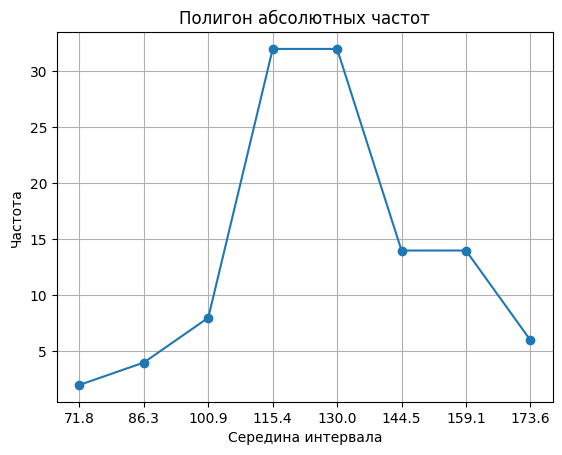

In [9]:
plt.plot(E3['mid_xi'], E3['mi'], 'o-')
plt.xticks(E3['mid_xi'])
plt.title('Полигон абсолютных частот')
plt.xlabel('Середина интервала')
plt.ylabel('Частота')
plt.grid()
plt.show()

#### Построение гистограммы

In [10]:
heights = E3['mi'] / h
heights

,mi
0,0.137457
1,0.274914
2,0.549828
3,2.199313
4,2.199313
5,0.962199
6,0.962199
7,0.412371


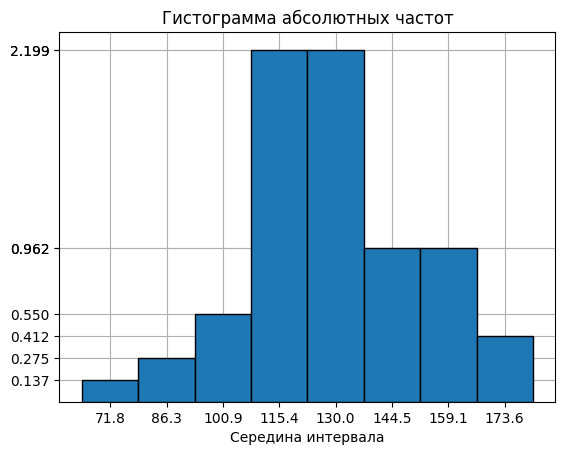

In [11]:
plt.bar(E3['mid_xi'], heights, width=h, edgecolor='black', zorder=3)
plt.title('Гистограмма абсолютных частот')
plt.xlabel('Середина интервала')
plt.xticks(E3['mid_xi'])
plt.yticks(heights)
plt.grid(zorder=0)
plt.show()

#### Построение эмпирической функции

In [12]:
f_star = E2['count'].cumsum()
f_star

,count
0,1
1,2
2,3
3,4
4,5
...,...
99,108
100,109
101,110
102,111


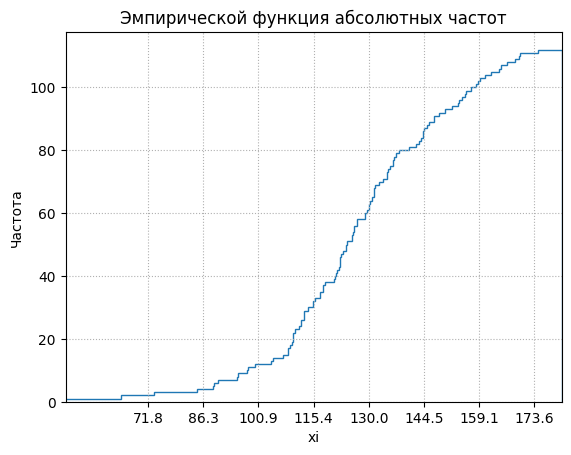

In [13]:
edges = [0]
edges.extend(E2['E'].to_list())
plt.xlim(50, E2['E'].max())
plt.grid(ls='dotted')
plt.title('Эмпирической функция абсолютных частот')
plt.xticks(E3['mid_xi'])
plt.xlabel('xi')
plt.ylabel('Частота')
plt.stairs(f_star, edges)
plt.show()

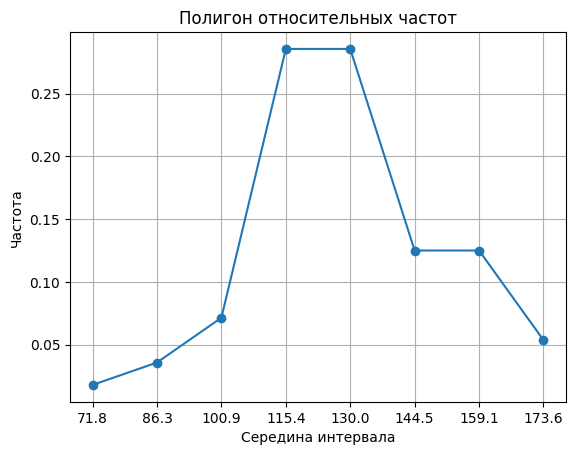

In [14]:
plt.plot(E3['mid_xi'], E3['rel_mi'], 'o-')
plt.xticks(E3['mid_xi'])
plt.title('Полигон относительных частот')
plt.xlabel('Середина интервала')
plt.ylabel('Частота')
plt.grid()
plt.show()

In [15]:
heights = E3['rel_mi'] / h
heights

,rel_mi
0,0.001227
1,0.002455
2,0.004909
3,0.019637
4,0.019637
5,0.008591
6,0.008591
7,0.003682


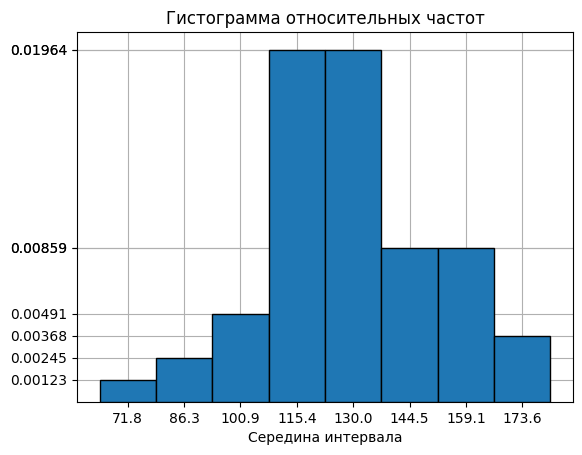

In [16]:
plt.bar(E3['mid_xi'], heights, width=h, edgecolor='black', zorder=3)
plt.title('Гистограмма относительных частот')
plt.xlabel('Середина интервала')
plt.xticks(E3['mid_xi'])
plt.yticks(heights,)
plt.grid(zorder=0)
plt.show()

In [17]:
f_star = E2['frequency'].cumsum()
f_star

,frequency
0,0.008929
1,0.017857
2,0.026786
3,0.035714
4,0.044643
...,...
99,0.964286
100,0.973214
101,0.982143
102,0.991071


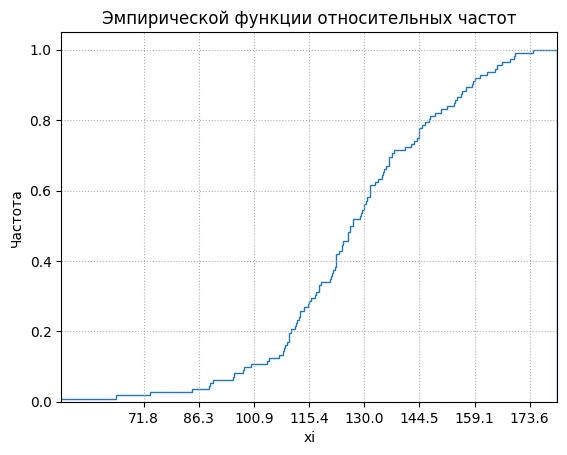

In [18]:
edges = [0]
edges.extend(E2['E'].to_list())
plt.xlim(50, E2['E'].max())
plt.grid(ls='dotted')
plt.title('Эмпирической функции относительных частот')
plt.xticks(E3['mid_xi'])
plt.xlabel('xi')
plt.ylabel('Частота')
plt.stairs(f_star, edges)
plt.show()

In [19]:
E4 = E3[['mid_xi', 'rel_mi']]
E4 = E4.rename(columns={'rel_mi': 'ni'})
E4.head()

,mid_xi,ni
0,71.775,0.017857
1,86.325,0.035714
2,100.875,0.071429
3,115.425,0.285714
4,129.975,0.285714


In [20]:
C = E4['mid_xi'][len(E4) // 2]
h = E4['mid_xi'][1] - E4['mid_xi'][0]

E4.loc[:,'ui'] = ((E4.loc[:, 'mid_xi'] - C ) / h).astype(int)

for i in range(1, 5):
  E4.loc[:,f'ni*ui^{i}'] = (E4.loc[:, 'ni'] * E4.loc[:, 'ui'] ** i)
E4.loc[:,f'ni*(ui + 1)^{4}'] = (E4.loc[:, 'ni'] * (E4.loc[:, 'ui'] + 1) ** 4)

E4.loc['Σ'] = [None, E4['ni'].sum(), None, E4['ni*ui^1'].sum(), E4['ni*ui^2'].sum(), E4['ni*ui^3'].sum(), E4['ni*ui^4'].sum(), E4['ni*(ui + 1)^4'].sum()]
E4

,mid_xi,ni,ui,ni*ui^1,ni*ui^2,ni*ui^3,ni*ui^4,ni*(ui + 1)^4
0,71.775,0.017857,-4.0,-0.071429,0.285714,-1.142857,4.571429,1.446429
1,86.325,0.035714,-3.0,-0.107143,0.321429,-0.964286,2.892857,0.571429
2,100.875,0.071429,-2.0,-0.142857,0.285714,-0.571429,1.142857,0.071429
3,115.425,0.285714,-1.0,-0.285714,0.285714,-0.285714,0.285714,0.000000
4,129.975,0.285714,0.0,0.000000,0.000000,0.000000,0.000000,0.285714
5,144.525,0.125000,1.0,0.125000,0.125000,0.125000,0.125000,2.000000
6,159.075,0.125000,2.0,0.250000,0.500000,1.000000,2.000000,10.125000
7,173.625,0.053571,3.0,0.160714,0.482143,1.446429,4.339286,13.714286
Σ,NaN,1.000000,NaN,-0.071429,2.285714,-0.392857,15.357143,28.214286


In [21]:
E4.iloc[-1, -2] + 4 * E4.iloc[-1, -3] + 6 * E4.iloc[-1, -4] + 4 * E4.iloc[-1, -5] + 1 - E4.iloc[-1, -1]

np.float64(0.0)

In [22]:
E5 = pd.DataFrame(index=range(1, 5), columns=['M^*k', 'mk'])
for i in range(1, 5):
  E5.loc[i, 'M^*k'] = E4.iloc[-1, 2 + i]


M1 = E5.loc[1, 'M^*k']
M2 = E5.loc[2, 'M^*k']
M3 = E5.loc[3, 'M^*k']
M4 = E5.loc[4, 'M^*k']
E5.loc[1, 'mk'] = 0
E5.loc[2, 'mk'] = (M2 - M1 ** 2) * (h ** 2)
E5.loc[3, 'mk'] = (M3 - 3 * M2 * M1 + 2 * M1 ** 3) * (h ** 3)
E5.loc[4, 'mk'] = (M4 - 4 * M3 * M1 + 6 * M2 * M1 ** 2 - 3 * M1 ** 4) * (h ** 4)
E5

,M^*k,mk
1,-0.071429,0
2,2.285714,482.811314
3,-0.392857,296.35264
4,15.357143,686377.501524


##### Выборочное среднее $\bar{x}_в$

In [23]:
# Через условные варианты
xv1 = E5.iloc[0,0] * h + C

# Через стандартную формулу
xv2 = E4.loc[:7, 'mid_xi'].to_numpy().dot(E4.loc[:7, 'ni'])
print(f"Выборочные среднее через условные варианты: {xv1} \nВыборочные среднее через стандартные формулы: {xv2} \nРазница: {xv1 - xv2}")

Выборочные среднее через условные варианты: 128.93571428571428 
Выборочные среднее через стандартные формулы: 128.93571428571428 
Разница: 0.0


Выборочная дисперсия $D_в$

In [24]:
# Через условные варианты
D1 = E5.loc[2, 'mk']

# Через стандартную формулу
D2 = ((E4.loc[:7, 'mid_xi'] - xv2) ** 2).to_numpy().dot(E4.loc[:7, 'ni'].to_numpy())
print(f"Дисперсия через условные варианты: {D1} \nДисперсия через стандартные формулы: {D2} \nРазница: {D1 - D2}")

Дисперсия через условные варианты: 482.811313775509 
Дисперсия через стандартные формулы: 482.8113137755102 
Разница: -1.1937117960769683e-12


##### Выборочное СКО $σ_в$

In [25]:
print(np.sqrt(D1))

21.972967796260683


In [26]:
# Исправленная дисперсия
s2 = N * D1 / (N - 1)
# Исправленное СКО
s = np.sqrt(s2)

print(f"Исправленная дисперсия: {s2} \nИсправленное СКО: {s} \nРазница: \nДисперсий: {s2 - D1} \n СКО: {s - np.sqrt(D1)}")

Исправленная дисперсия: 487.16096525096407 
Исправленное СКО: 22.07172320529061 
Разница: 
Дисперсий: 4.349651475455062 
 СКО: 0.09875540902992697


In [27]:
As = E5.loc[3, 'mk'] / (s ** 3)
E = E5.loc[4, 'mk'] / (s ** 4) - 3
print(f"Статистическая оценка коэффициента асимметрии: {As} \nСтатистическая оценка эксцесса: {E}")

Статистическая оценка коэффициента асимметрии: 0.027561323989080424 
Статистическая оценка эксцесса: -0.10786823857791683


In [28]:
E3

,[xi; xi+1),mid_xi,mi,rel_mi,s_mi,s_rel_mi
0,[64.50; 79.05),71.775,2,0.017857,2,0.017857
1,[79.05; 93.60),86.325,4,0.035714,6,0.053571
2,[93.60; 108.15),100.875,8,0.071429,14,0.125000
3,[108.15; 122.70),115.425,32,0.285714,46,0.410714
4,[122.70; 137.25),129.975,32,0.285714,78,0.696429
5,[137.25; 151.80),144.525,14,0.125000,92,0.821429
6,[151.80; 166.35),159.075,14,0.125000,106,0.946429
7,[166.35; 180.90],173.625,6,0.053571,112,1.000000


Так как частоты 3-го и 4-го интервалов одинаковы для расчета моды и медианы объеденим интервалы 1 и 2, 3 и 4, 5 и 6.

In [29]:
E3.loc[3:4, 'rel_mi'].sum()

np.float64(0.5714285714285714)

In [30]:
(E3.loc[:2, 'rel_mi']).sum()

np.float64(0.125)

In [31]:
Mo = 108.15 + h * 2 * (E3.loc[3:4, 'rel_mi'].sum() - E3.loc[1:2, 'rel_mi'].sum()) / ((E3.loc[3:4, 'rel_mi'].sum() - E3.loc[1:2, 'rel_mi'].sum()) + E3.loc[3:4, 'rel_mi'].sum() - E3.loc[5:6, 'rel_mi'].sum())
Me = 108.15 + h * 2 / E3.loc[3:4, 'rel_mi'].sum() * (0.5 - (E3.loc[:2, 'rel_mi']).sum())
V = np.sqrt(D2) / xv2 * 100

print(f"Мода: {Mo} \nМедиана: {Me} \nКоэффициент вариации: {V}%")

Мода: 125.34545454545453 
Медиана: 127.24687499999999 
Коэффициент вариации: 17.041800961035396%


Итого получим таблицу:

| $\bar{x}_в$    |  128.935 |
|----------|:-:|
|    $D_в$   |  482.811 |
| $\sigma_в$ |  21.973 |
|   $\bar{A}_s$  | 0.0276  |
|   $\bar{E}_s$  |  -0.1079 |
|   $M^*_o$  | 125.345  |
|   $M^*_e$  |  127.247 |
|    $V^*$   |  17.042 |

Коэффициент асимметрии больше нуля, следовательно большинство элементов выборки находится слева от среднего значения; медиана больше моды, что соответствует таблице.

Коэффициент эксцесса меньше нуля, следовательно пик более плоский

Коэффициент вариации параметра $E$ больше, чем у параметра $\nu$ (равного 11.964 из ПР2), следовательно его разброс относительно выборочного среднего больше.

### Задание 2

Построить двумерный интервальный вариационный ряд, оформить в виде таблицы.

Загрузка интервального ряда первого параметра, полученного в ПР1

In [32]:
nu3 = pd.read_csv('is.csv', index_col=0)
nu3

,[xi; xi+1),mid_xi,mi,rel_mi,s_mi,s_rel_mi
0,[320.0; 353.875),336.9375,3,0.026786,3,0.026786
1,[353.875; 387.75),370.8125,8,0.071429,11,0.098214
2,[387.75; 421.625),404.6875,18,0.160714,29,0.258929
3,[421.625; 455.5),438.5625,28,0.250000,57,0.508929
4,[455.5; 489.375),472.4375,24,0.214286,81,0.723214
5,[489.375; 523.25),506.3125,18,0.160714,99,0.883929
6,[523.25; 557.125),540.1875,8,0.071429,107,0.955357
7,[557.125; 591.0],574.0625,5,0.044643,112,1.000000


Объединение таблиц интервальных рядов в одну таблицу

In [33]:
df1 = pd.concat([
    nu3.rename(columns={
    '[xi; xi+1)': '[nui; nui+1)',
    'mid_xi': 'mid_nui',
    'mi': 'mi_nu',
    'rel_mi': 'rel_mi_nu',
    's_mi': 's_mi_nu',
    's_rel_mi': 's_rel_mi_nu'
    }),
    E3.rename(columns={
    '[xi; xi+1)': '[Ei; Ei+1)',
    'mid_xi': 'mid_Ei',
    'mi': 'mi_E',
    'rel_mi': 'rel_mi_E',
    's_mi': 's_mi_E',
    's_rel_mi': 's_rel_mi_E'
    })
], axis=1)

df1

,[nui; nui+1),mid_nui,mi_nu,rel_mi_nu,s_mi_nu,s_rel_mi_nu,[Ei; Ei+1),mid_Ei,mi_E,rel_mi_E,s_mi_E,s_rel_mi_E
0,[320.0; 353.875),336.9375,3,0.026786,3,0.026786,[64.50; 79.05),71.775,2,0.017857,2,0.017857
1,[353.875; 387.75),370.8125,8,0.071429,11,0.098214,[79.05; 93.60),86.325,4,0.035714,6,0.053571
2,[387.75; 421.625),404.6875,18,0.160714,29,0.258929,[93.60; 108.15),100.875,8,0.071429,14,0.125000
3,[421.625; 455.5),438.5625,28,0.250000,57,0.508929,[108.15; 122.70),115.425,32,0.285714,46,0.410714
4,[455.5; 489.375),472.4375,24,0.214286,81,0.723214,[122.70; 137.25),129.975,32,0.285714,78,0.696429
5,[489.375; 523.25),506.3125,18,0.160714,99,0.883929,[137.25; 151.80),144.525,14,0.125000,92,0.821429
6,[523.25; 557.125),540.1875,8,0.071429,107,0.955357,[151.80; 166.35),159.075,14,0.125000,106,0.946429
7,[557.125; 591.0],574.0625,5,0.044643,112,1.000000,[166.35; 180.90],173.625,6,0.053571,112,1.000000


Итоговая таблица:

|    | $[\nu_i$; $\nu_{i+1}$)      |   $\tilde{\nu}_i$ |   m $_{\nu, i}$ |   $\tilde{m}_{\nu,i}$ |   $m_{\nu,i}^{нак}$ |   $\tilde{m}_{\nu,i}^{нак}$ | $[E_i$; $E_{i+1}$)       |   $\tilde{E}_i$ |   $m_{E,i}$ |   $\tilde{m}_{E,i}$ |   $m_{E,i}^{нак}$ |   $\tilde{m}_{E,i}^{нак}$ |
|---:|:------------------|----------:|--------:|------------:|----------:|--------------:|:-----------------|---------:|-------:|-----------:|---------:|-------------:|
|  0 | [320.0; 353.875)  |   336.938 |       3.0 |   0.0267857 |         3 |     0.0267857 | [64.50; 79.05)   |   71.775 |      2.0 |  0.0178571 |        2 |    0.0178571 |
|  1 | [353.875; 387.75) |   370.812 |       8.0 |   0.0714286 |        11 |     0.0982143 | [79.05; 93.60)   |   86.325 |      4.0 |  0.0357143 |        6 |    0.0535714 |
|  2 | [387.75; 421.625) |   404.688 |      18.0 |   0.160714  |        29 |     0.258929  | [93.60; 108.15)  |  100.875 |      8.0 |  0.0714286 |       14 |    0.125     |
|  3 | [421.625; 455.5)  |   438.562 |      28.0 |   0.25      |        57 |     0.508929  | [108.15; 122.70) |  115.425 |     32.0 |  0.285714  |       46 |    0.410714  |
|  4 | [455.5; 489.375)  |   472.438 |      24.0 |   0.214286  |        81 |     0.723214  | [122.70; 137.25) |  129.975 |     32.0 |  0.285714  |       78 |    0.696429  |
|  5 | [489.375; 523.25) |   506.312 |      18.0 |   0.160714  |        99 |     0.883929  | [137.25; 151.80) |  144.525 |     14.0 |  0.125     |       92 |    0.821429  |
|  6 | [523.25; 557.125) |   540.188 |       8.0 |   0.0714286 |       107 |     0.955357  | [151.80; 166.35) |  159.075 |     14.0 |  0.125     |      106 |    0.946429  |
|  7 | [557.125; 591.0]  |   574.062 |       5.0 |   0.0446429 |       112 |     1         | [166.35; 180.90] |  173.625 |      6.0 |  0.0535714 |      112 |    1         |

### Задание 3
По полученному двумерному интервальному вариационному ряду построить корреляционную таблицу, сделать выводы.

In [34]:
df2 = pd.DataFrame(
    columns=nu3['[xi; xi+1)'].to_list() + ['n_E'],
    index=E3['[xi; xi+1)'].to_list() + ['n_nu'],
    dtype=np.int64
)
df2 = df2.fillna(0).astype(np.int64)

for _, row in df.iterrows():
  nu_val = row['nu']
  nu_idx = 7
  for i in range(len(df2.columns) - 1):
    tmp = df2.columns[i][1:-1].split(';')
    if nu_val >= float(tmp[0]) and nu_val < float(tmp[1]):
      nu_idx = i

  E_val = row['E']
  E_idx = 7
  for i in range(len(df2.index) - 1):
    tmp = df2.index[i][1:-1].split(';')
    if E_val >= float(tmp[0]) and E_val < float(tmp[1]):
      E_idx = i

  df2.iloc[E_idx, nu_idx] += 1
for i in range(len(df2.columns)):
  df2.iloc[i, -1] = df2.iloc[i, :].sum()
  df2.iloc[-1, i] = df2.iloc[:, i].sum()

df2.iloc[-1,-1] //= 2
df2


,[320.0; 353.875),[353.875; 387.75),[387.75; 421.625),[421.625; 455.5),[455.5; 489.375),[489.375; 523.25),[523.25; 557.125),[557.125; 591.0],n_E
[64.50; 79.05),1,0,1,0,0,0,0,0,2
[79.05; 93.60),2,1,1,0,0,0,0,0,4
[93.60; 108.15),0,4,1,2,1,0,0,0,8
[108.15; 122.70),0,3,11,12,5,1,0,0,32
[122.70; 137.25),0,0,4,14,9,5,0,0,32
[137.25; 151.80),0,0,0,0,7,6,1,0,14
[151.80; 166.35),0,0,0,0,2,5,6,1,14
[166.35; 180.90],0,0,0,0,0,1,1,4,6
n_nu,3,8,18,28,24,18,8,5,112


Получим таблицу

|       E \ $\nu$           |   [320.0; 353.875) |   [353.875; 387.75) |   [387.75; 421.625) |   [421.625; 455.5) |   [455.5; 489.375) |   [489.375; 523.25) |   [523.25; 557.125) |   [557.125; 591.0] |   $n_E$ |
|:-----------------|-------------------:|--------------------:|--------------------:|-------------------:|-------------------:|--------------------:|--------------------:|-------------------:|------:|
| [64.50; 79.05)   |                  1 |                     |                   1 |                    |                    |                     |                     |                    |     2 |
| [79.05; 93.60)   |                  2 |                   1 |                   1 |                    |                    |                     |                     |                    |     4 |
| [93.60; 108.15)  |                    |                   4 |                   1 |                  2 |                  1 |                     |                     |                    |     8 |
| [108.15; 122.70) |                    |                   3 |                  11 |                 12 |                  5 |                   1 |                     |                    |    32 |
| [122.70; 137.25) |                    |                     |                   4 |                 14 |                  9 |                   5 |                     |                    |    32 |
| [137.25; 151.80) |                    |                     |                     |                    |                  7 |                   6 |                   1 |                    |    14 |
| [151.80; 166.35) |                    |                     |                     |                    |                  2 |                   5 |                   6 |                  1 |    14 |
| [166.35; 180.90] |                    |                     |                     |                    |                    |                   1 |                   1 |                  4 |     6 |
| $n_{\nu}$             |                  3 |                   8 |                  18 |                 28 |                 24 |                  18 |                   8 |                  5 |   112 |

#### Задание 4
Исходя из результатов корреляционной таблицы вычислить значение выборочного коэффициента корреляции двумя способами: с помощью стандартной формулы и с помощью условных вариант. Убедиться, что результаты совпадают. Сделать выводы.

Для рассчета статистической оценки каждому интервалу сопоставим его среднее значение.

#### Через стандартные формулы

In [35]:
r1 = 0
for i in range(len(E3)):
  for j in range(len(nu3)):
    r1 += df2.iloc[i, j] * E3.iloc[i, 1] * nu3.iloc[j, 1]
# 457.0122767857143 --- выборочное среднее nu из ПР2
r1 -= N * xv2 * 457.0122767857143

# 54.675864731176944 --- СКО nu из ПР2
r1 /= (N * np.sqrt(D1) * 54.675864731176944)
r1

np.float64(0.8291518965425814)

Через условные варианты

In [36]:
C_nu = nu3['mid_xi'][len(nu3) // 2]
h_nu = nu3['mid_xi'][1] - nu3['mid_xi'][0]

C_E = E3['mid_xi'][len(E3) // 2]
h_E = E3['mid_xi'][1] - E3['mid_xi'][0]

u = (nu3['mid_xi'] - C_nu) / h_nu
v = (E3['mid_xi'] - C_E) / h_E

uv = 1/N * (u.to_numpy().dot(nu3['mi'].to_numpy()))
vv = 1/N * (v.to_numpy().dot(E3['mi'].to_numpy()))

sigma_u = np.sqrt((u**2).to_numpy().dot(nu3['mi'].to_numpy()) / N - uv**2)
sigma_v = np.sqrt((v**2).to_numpy().dot(E3['mi'].to_numpy()) / N - vv**2)

r2 = 0

for i in range(len(v)):
  for j in range(len(u)):
    r2 += df2.iloc[i, j] * v.iloc[i] * u.iloc[j]

r2 -= N * uv * vv
r2 /= (N * sigma_u * sigma_v)
r2

np.float64(0.8291518965425748)

In [37]:
r1 - r2

np.float64(6.5503158452884236e-15)

Значения выборочного коэффициента корреляции почти совпадают. Разница возникла из-за ошибок округления при вычислениях.


### Задание 5
Построить доверительный интервал для коэффициента корреляции при уровне значимости $\gamma \in \{0.95, 0.99\}$, сделать выводы.

In [38]:
gamma = [0.95, 0.99]

# lam получено из приложения 4 как аргументы функции Лапласа для значений функции 0.475, 0.495
lam = [1.96, 2.58]

zv = 0.5 * np.log((1 + r1) / (1 - r1))
sigma_z = 1 / np.sqrt(N - 3)

left = []
right = []
for i in range(2):
  lz = zv - lam[i] * sigma_z
  rz = zv + lam[i] * sigma_z
  left.append((np.exp(2 * lz) - 1) / (np.exp(2 * lz) + 1))
  right.append((np.exp(2 * rz) - 1) / (np.exp(2 * rz) + 1))
  print(f"Доверительный интервал коэффициента корреляции с доверительной точностью {gamma[i]}: ({left[i]}; {right[i]})")

Доверительный интервал коэффициента корреляции с доверительной точностью 0.95: (0.7606191277807274; 0.8794081761366247)
Доверительный интервал коэффициента корреляции с доверительной точностью 0.99: (0.7344389367071571; 0.8921850458613232)


### Задание 6

Осуществить проверку статистической гипотезы о равенстве коэффициента корреляции нулю при заданном уровне значимости $α = 0.05$, сделать выводы.

Число степеней свободы $k = N -2 = 110$
Критическая точка распределения Стьюдента $t_{крит}(0.05, 110) = 1.98$, получено из приложения 8

In [39]:
T = r1 * np.sqrt(N - 2) / (np.sqrt(1 - r1**2))
T

np.float64(15.556090967225623)

$|T| > t_{крит}(0.05, 110)$, следовательно гипотеза о равенстве коэффициента корреляции нулю отвергается. Выборочный коэффициент корреляции значим.

## Выводы

Была проверена наличие корреляционной зависимости между двумя величинами выборки $\nu$ и $E$. Была построена таблица корреляции двух величин. По таблице был найден выборочный коэффициент корреляции. Был найден доверительный интервал коэффициента корреляции. Была проверена гипотеза о равенстве коэффициента корреляции нулю, которая была отвергнута, что говорит о корреляционной зависимости двух величин.